# LOB Extensions: Glosten–Milgrom and Inventory Risk
## Two Independent Branches on the Baseline Bertrand–Ma-Noh Model

This notebook extends the baseline unified-trader MFG with two alternative mechanisms for generating an endogenous bid-ask spread. Each branch is independent and toggled via parameters.

### Why these two branches?

In the baseline model, the Bertrand spread collapses to the no-arbitrage floor because impatient LPs with large margins always prefer to post near $p$. Two natural mechanisms can push LP posting away from the floor:

**Branch A: Glosten–Milgrom adverse selection.** A fraction $\pi$ of arriving traders are *informed* — they trade on private information about the true event probability $p'$. LPs who get filled by informed traders systematically lose money. The effective margin shrinks:
$$m_{\text{eff}}(a, v) = a(1-f) - v - \Delta_{\text{AS}}, \qquad \Delta_{\text{AS}} = \pi \cdot \sigma_s$$
This is the canonical market-maker spread.

**Branch B: Inventory risk.** The fundamental $p_t$ follows Brownian motion $dp_t = \sigma_p\, dW_t$. A risk-averse LP holding depth $q$ bears mark-to-market variance proportional to $q^2$. Following Avellaneda–Stoikov, a CARA approximation adds a running cost to the HJB:
$$rV_n = \max_l \left\{\, \text{margin} \cdot \lambda_b^n - \tfrac{\kappa}{2}l^2 \, \mathbf{-\tfrac{\gamma}{2}\sigma_p^2\, (n\delta)^2} + \ldots \right\}$$

Both branches share the same Bertrand-MaNoh solver; only the HJB's margin and cost terms change.

## 1. Imports and Ma-Noh primitives

The stationary-distribution and quantile-update helpers are unchanged from the baseline.

In [1]:
import numpy as np
from scipy.stats import beta as beta_dist
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12, 'axes.labelsize': 14,
    'axes.titlesize': 14, 'legend.fontsize': 11, 'lines.linewidth': 2,
    'figure.dpi': 120,
})

In [2]:
def proj_0_lbar(x, lbar):
    return np.minimum(np.maximum(x, 0.0), lbar)

def rank_grid(N):
    return (np.arange(1, N+1) - 0.5) / N

def destination_indices(q, ds, db):
    q = np.asarray(q); N = q.size
    jp = np.empty(N, dtype=int); jm = np.empty(N, dtype=int)
    for i in range(N):
        jp[i] = int(np.argmin(np.abs(q - (q[i] + ds))))
        jm[i] = int(np.argmin(np.abs(q - max(q[i] - db, 0.0))))
    return jp, jm

def stat_dist(jp, jm, lp, lm):
    N = len(lp); rates = np.array(lp) + np.array(lm)
    bL = max(np.max(rates), 1e-12); P = np.zeros((N, N))
    for i in range(N):
        if rates[i] > 0:
            P[i, jp[i]] += lp[i]/bL; P[i, jm[i]] += lm[i]/bL
            P[i, i] += 1 - rates[i]/bL
        else: P[i, i] = 1
    m = np.ones(N)/N; PT = P.T
    for _ in range(80000):
        mn = PT @ m; s = mn.sum()
        if s <= 0: break
        mn /= s
        if np.max(np.abs(mn - m)) < 1e-14: m = mn; break
        m = mn
    return m

def quant_upd(u, q, m):
    M = np.cumsum(m); M = np.clip(M, 0, 1); Me = M.copy()
    for i in range(1, len(Me)):
        if Me[i] <= Me[i-1]: Me[i] = Me[i-1] + 1e-12
    return np.interp(u, np.clip(Me, 0, 1), q, left=q[0], right=q[-1])

## 2. Extended HJB solver

For depth state $n \ge 1$:
$$rV_n = \max_{l_n \in [0, \bar l]}\!\left\{ m_{\text{eff}} \, \delta_b \, \lambda_b^n - \tfrac{\kappa}{2} l_n^2 \; \mathbf{-\; \eta\, (n\delta)^2} + l_n \Psi(u_n)(V_{n+1} - V_n) + \lambda_b^n (V_{n-1} - V_n) \right\}$$

with $m_{\text{eff}} = a(1-f) - v - \Delta_{\text{AS}}$ and $\eta = \gamma \sigma_p^2$.

Setting $\Delta_{\text{AS}} = 0$, $\eta = 0$ recovers the baseline. The strict diagonal dominance (excess $= r > 0$) and closed-form optimal control $l_n^* = \Pi_{[0,\bar l]}(\Psi(u_n)(V_{n+1}-V_n)/\kappa)$ carry over unchanged — inventory risk is a pure running cost that doesn't affect the FOC in $l$.

In [3]:
def solve_hjb_extended(q, u, jp, jm, rho, kappa, l_bar, psi, theta,
                       margin_eff, db, mu_exec,
                       inventory_risk_coef=0.0,
                       max_iter=80, tol=1e-10):
    """
    HJB with optional inventory risk:
      r V_n = max_l { m_eff * delta_b * lam_b - (kappa/2) l^2
                      - inventory_risk_coef * (n*db)^2
                      + lam_s (V_{n+1}-V_n) + lam_b (V_{n-1}-V_n) }
    
    Glosten-Milgrom enters through margin_eff = (a(1-f) - v - Delta_AS).
    Inventory risk enters through inventory_risk_coef = (gamma * sigma_p^2).
    """
    N = len(q); Psi = 1 + psi*u; Theta = 1 + theta*(1-u)
    # Inventory-risk running cost: proportional to q^2 at each node
    q_arr = np.asarray(q)
    inv_cost = inventory_risk_coef * q_arr**2  # per unit time

    l = np.zeros(N); V = np.zeros(N)
    for it in range(max_iter):
        ls = l*Psi; lb = mu_exec*Theta
        # Profit flow from fills (only when q > 0)
        pi = margin_eff * lb * db * (q_arr > 0).astype(float)
        # Build linear system
        A = np.zeros((N, N)); b = np.zeros(N)
        for i in range(N):
            A[i, i] = rho + ls[i] + lb[i]
            A[i, jp[i]] -= ls[i]; A[i, jm[i]] -= lb[i]
            b[i] = pi[i] - 0.5*kappa*l[i]**2 - inv_cost[i]
        try: Vn = np.linalg.solve(A, b)
        except: break
        ln = proj_0_lbar((Psi/kappa)*(Vn[jp] - Vn), l_bar)
        if np.max(np.abs(ln - l)) < tol:
            V, l = Vn, ln
            break
        V, l = Vn, ln
    return V, l

## 3. Parameters

In [4]:
p_mid   = 0.65
fee     = 0.02
alpha_F = 6.5; beta_F = 3.5
lam_arr = 10.0
delta_s = 1.0; delta_b_size = 1.0
kappa   = 0.4; l_bar = 3.0; psi = 0.3; theta = 0.7
N_total = 100.0; r_min = 0.05; r_max = 2.0

# Grids (slightly smaller for faster comparison across branches)
N_v = 5; N_r = 5; N_a = 12; N_q = 30; q_max = 15.0

r_grid = r_min * (r_max/r_min)**np.linspace(0, 1, N_r)
omega = 0.10; outer_max = 14; cesaro_start = 8; sigma_smooth = 0.015

## 4. One-side solver with extension hooks

The solver runs the full nested equilibrium (policy iteration → quantile fixed-point → Bertrand fixed-point → Cesaro average) with optional GM and inventory-risk terms.

The function returns two candidate "best ask" measures:
- **Threshold-based** (lowest $a$ where $d(a) > 0.30 \cdot d_{\max}$): where substantial depth begins.
- **Peak-based** (location of the density mode): where the *mass* of LPs actually concentrates.

For prediction markets where a small floor-binding tail coexists with a distinct peak elsewhere, the peak-based measure is more economically informative — it captures where LPs *choose* to post rather than where the floor tail happens to sit.

In [5]:
def solve_one_side_extended(p_fund, alpha_beta, beta_beta, side_label,
                             gm_pi=0.0, gm_sigma_s=0.0,
                             inventory_gamma=0.0, fundamental_sigma=0.0,
                             verbose=True):
    """
    Solve the Bertrand-Ma-Noh equilibrium for one side with optional extensions.
    
    Args:
        gm_pi: Glosten-Milgrom informed-trader share in [0, 1]
        gm_sigma_s: signal magnitude (adverse selection = gm_pi * gm_sigma_s)
        inventory_gamma: LP risk aversion coefficient (>= 0)
        fundamental_sigma: fundamental volatility (>= 0)
        Inventory risk term: inventory_gamma * fundamental_sigma^2 * q^2
    """
    # Adverse selection loss per fill (constant approximation)
    Delta_AS = gm_pi * gm_sigma_s
    # Inventory risk coefficient
    inv_risk_coef = inventory_gamma * fundamental_sigma**2

    # LP valuations via Beta quantile
    v_upper = p_fund * (1 - fee) - Delta_AS  # account for AS loss in grid bound
    if v_upper <= 0.03:
        v_upper = 0.03
    p_cap = beta_dist.cdf(v_upper, alpha_beta, beta_beta)
    if p_cap < 0.05:
        v_grid_s = np.linspace(0.01, v_upper - 0.005, N_v)
    else:
        probs = np.linspace(0.05, 0.99, N_v) * p_cap
        v_grid_s = beta_dist.ppf(probs, alpha_beta, beta_beta)
        v_grid_s = np.sort(np.unique(np.clip(v_grid_s, 0.005, v_upper - 0.005)))
        while len(v_grid_s) < N_v:
            v_grid_s = np.concatenate([v_grid_s, [v_grid_s[-1] - 0.001]])
            v_grid_s = np.sort(np.unique(v_grid_s))

    # Ask grid: [p, 1-f]
    a_lo = p_fund + 1e-4
    a_hi = min(0.995, 1 - fee/2)
    if a_lo >= a_hi: a_lo = a_hi - 0.05
    t_grid = np.linspace(0, 1, N_a)**1.5
    a_grid_s = a_lo + (a_hi - a_lo) * t_grid

    def phi_s(a):
        return lam_arr * (1 - beta_dist.cdf(a, alpha_beta, beta_beta))

    def margin_eff(a, v):
        # Effective margin after fee and GM adverse selection
        return a * (1 - fee) - v - Delta_AS

    def solve_at(a_p, v_lp, rho, mu, ni=5):
        mg = margin_eff(a_p, v_lp)
        if mg <= 0.0005:
            return 0.0, 0.0
        u = rank_grid(N_q); q = np.linspace(0, q_max, N_q)
        for _ in range(ni):
            jp, jm = destination_indices(q, delta_s, delta_b_size)
            V, l = solve_hjb_extended(
                q, u, jp, jm, rho=rho, kappa=kappa, l_bar=l_bar,
                psi=psi, theta=theta, margin_eff=mg, db=delta_b_size,
                mu_exec=mu, inventory_risk_coef=inv_risk_coef,
                max_iter=60, tol=1e-10
            )
            Psi = 1 + psi*u; Theta = 1 + theta*(1-u)
            m = stat_dist(jp, jm, l*Psi, mu*np.ones_like(q)*Theta)
            qt = quant_upd(u, q, m)
            q = np.maximum(np.sort((1-0.15)*q + 0.15*qt), 0)
        return float(V[0]), float(np.dot(m, q))

    if verbose:
        print(f"\n--- {side_label} (p={p_fund:.3f}, pi={gm_pi}, gamma*sigma^2={inv_risk_coef:.4f}) ---")
        print(f"  Delta_AS = {Delta_AS:.4f}, ask grid: [{a_grid_s[0]:.4f}, {a_grid_s[-1]:.4f}]")

    # Trapezoidal weights for non-uniform v_grid
    dv_w = np.zeros(N_v)
    if N_v > 1:
        dv_w[0] = (v_grid_s[1] - v_grid_s[0]) / 2
        dv_w[-1] = (v_grid_s[-1] - v_grid_s[-2]) / 2
        for k in range(1, N_v - 1):
            dv_w[k] = (v_grid_s[k+1] - v_grid_s[k-1]) / 2
    else: dv_w[0] = 1.0
    dr_w = np.zeros(N_r)
    if N_r > 1:
        dr_w[0] = (r_grid[1] - r_grid[0]) / 2
        dr_w[-1] = (r_grid[-1] - r_grid[-2]) / 2
        for lidx in range(1, N_r - 1):
            dr_w[lidx] = (r_grid[lidx+1] - r_grid[lidx-1]) / 2
    else: dr_w[0] = 1.0

    # Outer Bertrand fixed point
    D_a = np.ones(N_a) * 2.0
    D_ces = np.zeros(N_a); ces_n = 0
    a_star_2d = np.zeros((N_v, N_r))
    d_bar_2d = np.zeros((N_v, N_r))
    t0 = time.time()

    for oit in range(outer_max):
        mu_a = phi_s(a_grid_s) / np.maximum(D_a, 0.01)
        for kv in range(N_v):
            for kr in range(N_r):
                best = -np.inf; bj = 0; bdb = 0.0
                for j in range(N_a):
                    if margin_eff(a_grid_s[j], v_grid_s[kv]) <= 0.0005: continue
                    ni = 3 if oit < 6 else 5
                    V0j, dbj = solve_at(a_grid_s[j], v_grid_s[kv], r_grid[kr], mu_a[j], ni=ni)
                    if V0j > best: best = V0j; bj = j; bdb = dbj
                a_star_2d[kv, kr] = a_grid_s[bj]
                d_bar_2d[kv, kr] = bdb

        D_new = np.zeros(N_a)
        step = np.diff(a_grid_s)
        step_at = np.concatenate([[step[0]], (step[:-1]+step[1:])/2, [step[-1]]])
        for kv in range(N_v):
            for kr in range(N_r):
                fv = beta_dist.pdf(v_grid_s[kv], alpha_beta, beta_beta)
                gr = 1.0 / (r_max - r_min)
                w = N_total * fv * dv_w[kv] * gr * dr_w[kr] * d_bar_2d[kv, kr]
                kern = np.exp(-0.5*((a_grid_s - a_star_2d[kv, kr])/sigma_smooth)**2)
                kern_norm = np.sum(kern * step_at) + 1e-20
                D_new += w * kern / kern_norm
        D_new = np.maximum(D_new, 0.005)
        D_a = (1 - omega) * D_a + omega * D_new
        if oit >= cesaro_start:
            ces_n += 1
            D_ces += (D_a - D_ces) / ces_n

    D_final = D_ces if ces_n > 0 else D_a
    D_cum = np.zeros(N_a)
    for i in range(N_a):
        if len(a_grid_s[i:]) > 1:
            D_cum[i] = np.trapz(D_final[i:], a_grid_s[i:])

    # Two definitions of "best ask":
    # (a) threshold-based: lowest a with density above 30% of peak
    #     (captures where substantial depth begins)
    # (b) peak-based: location of the density mode
    #     (captures where most LPs actually post — often more economically relevant
    #      for prediction markets where floor depth is sparse)
    thresh = 0.30 * D_final.max()
    above = np.where(D_final > thresh)[0]
    best_idx = above[0] if len(above) > 0 else 0
    best_ask = a_grid_s[best_idx]
    # Also report the peak-based "effective" best ask
    peak_idx = int(np.argmax(D_final))
    best_ask_peak = a_grid_s[peak_idx]

    if verbose:
        print(f"  Done [{time.time()-t0:.0f}s]. Best ask = {best_ask:.4f}, "
              f"floor binds = {best_idx <= 1}")

    return {
        'a_grid': a_grid_s, 'd': D_final, 'd_cum': D_cum,
        'a_star_2d': a_star_2d, 'd_bar_2d': d_bar_2d, 'v_grid': v_grid_s,
        'best_ask': best_ask, 'best_ask_peak': best_ask_peak,
        'floor_binds': best_idx <= 1,
        'Delta_AS': Delta_AS, 'inv_risk_coef': inv_risk_coef
    }

## 5. Full-LOB wrapper

Runs both YES and NO sides with the given extension parameters, computes the spread via the two definitions.

In [6]:
def compute_full_lob(gm_pi=0.0, gm_sigma_s=0.0,
                      inventory_gamma=0.0, fundamental_sigma=0.0,
                      label='baseline'):
    """Run YES and NO sides with the given extension parameters."""
    print(f"\n{'='*60}\nScenario: {label}\n{'='*60}")
    yes_out = solve_one_side_extended(
        p_mid, alpha_F, beta_F, 'YES',
        gm_pi=gm_pi, gm_sigma_s=gm_sigma_s,
        inventory_gamma=inventory_gamma, fundamental_sigma=fundamental_sigma
    )
    no_out = solve_one_side_extended(
        1 - p_mid, beta_F, alpha_F, 'NO',
        gm_pi=gm_pi, gm_sigma_s=gm_sigma_s,
        inventory_gamma=inventory_gamma, fundamental_sigma=fundamental_sigma
    )
    spread = yes_out['best_ask'] + no_out['best_ask'] - 1.0
    spread_peak = yes_out['best_ask_peak'] + no_out['best_ask_peak'] - 1.0
    b_best = 1 - no_out['best_ask']
    b_best_peak = 1 - no_out['best_ask_peak']
    print(f"\n{label}:")
    print(f"  Threshold-based: YES={yes_out['best_ask']:.4f}, NO={no_out['best_ask']:.4f}, "
          f"spread={spread:.4f}")
    print(f"  Peak-based:      YES={yes_out['best_ask_peak']:.4f}, NO={no_out['best_ask_peak']:.4f}, "
          f"spread={spread_peak:.4f}")
    return yes_out, no_out, spread, spread_peak

## 6. Run three scenarios

- **Baseline**: no extensions
- **Glosten–Milgrom**: $\pi = 0.40$, $\sigma_s = 0.30$ → $\Delta_{\text{AS}} = 0.12$ per fill. These are strong (high informed-trader share and meaningful signal magnitude) but economically plausible for an illiquid prediction market on a volatile asset like BTC.
- **Inventory risk**: $\gamma = 2.0$ (moderate risk aversion), $\sigma_p = 0.25$ → risk coefficient $\gamma \sigma_p^2 = 0.125$.

In [7]:
print("Branch Comparison: Baseline vs GM vs Inventory Risk")
print("="*60)

# Baseline (no extensions)
yes_b, no_b, s_b, sp_b = compute_full_lob(label='Baseline (no extensions)')

yes_gm, no_gm, s_gm, sp_gm = compute_full_lob(gm_pi=0.40, gm_sigma_s=0.30,
                                                label='GM (pi=0.40, sigma_s=0.30)')

yes_iv, no_iv, s_iv, sp_iv = compute_full_lob(inventory_gamma=2.0, fundamental_sigma=0.25,
                                                label='Inventory (gamma=2.0, sigma_p=0.25)')

Branch Comparison: Baseline vs GM vs Inventory Risk

Scenario: Baseline (no extensions)

--- YES (p=0.650, pi=0.0, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.0000, ask grid: [0.6501, 0.9900]
  Done [125s]. Best ask = 0.6501, floor binds = True

--- NO (p=0.350, pi=0.0, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.0000, ask grid: [0.3501, 0.9900]
  Done [111s]. Best ask = 0.3501, floor binds = True

Baseline (no extensions):
  Threshold-based: YES=0.6501, NO=0.3501, spread=0.0002
  Peak-based:      YES=0.6985, NO=0.3997, spread=0.0982

Scenario: GM (pi=0.40, sigma_s=0.30)

--- YES (p=0.650, pi=0.4, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.1200, ask grid: [0.6501, 0.9900]
  Done [41s]. Best ask = 0.6501, floor binds = True

--- NO (p=0.350, pi=0.4, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.1200, ask grid: [0.3501, 0.9900]
  Done [55s]. Best ask = 0.3501, floor binds = True

GM (pi=0.40, sigma_s=0.30):
  Threshold-based: YES=0.6501, NO=0.3501, spread=0.0002
  Peak-based:      YES=0.7543, NO=0.49

## 7. Spread comparison

In [8]:
print("SPREAD COMPARISON")
print(f"{'='*60}")
print(f"{'Scenario':<20} {'Threshold spread':>18} {'Peak spread':>15}")
print("-" * 60)
print(f"{'Baseline':<20} {s_b:>18.4f} {sp_b:>15.4f}")
print(f"{'Glosten-Milgrom':<20} {s_gm:>18.4f} {sp_gm:>15.4f}")
print(f"{'Inventory risk':<20} {s_iv:>18.4f} {sp_iv:>15.4f}")


# ================================================================

SPREAD COMPARISON
Scenario               Threshold spread     Peak spread
------------------------------------------------------------
Baseline                         0.0002          0.0982
Glosten-Milgrom                  0.0002          0.2447
Inventory risk                   0.0002          0.0486


## 8. Visualisation


FINAL SUMMARY
Scenario               Best YES   Best NO    Thr spread   Peak spread 
----------------------------------------------------------------------
Baseline               0.6501     0.3501     0.0002       0.0982      
Glosten-Milgrom        0.6501     0.3501     0.0002       0.2447      


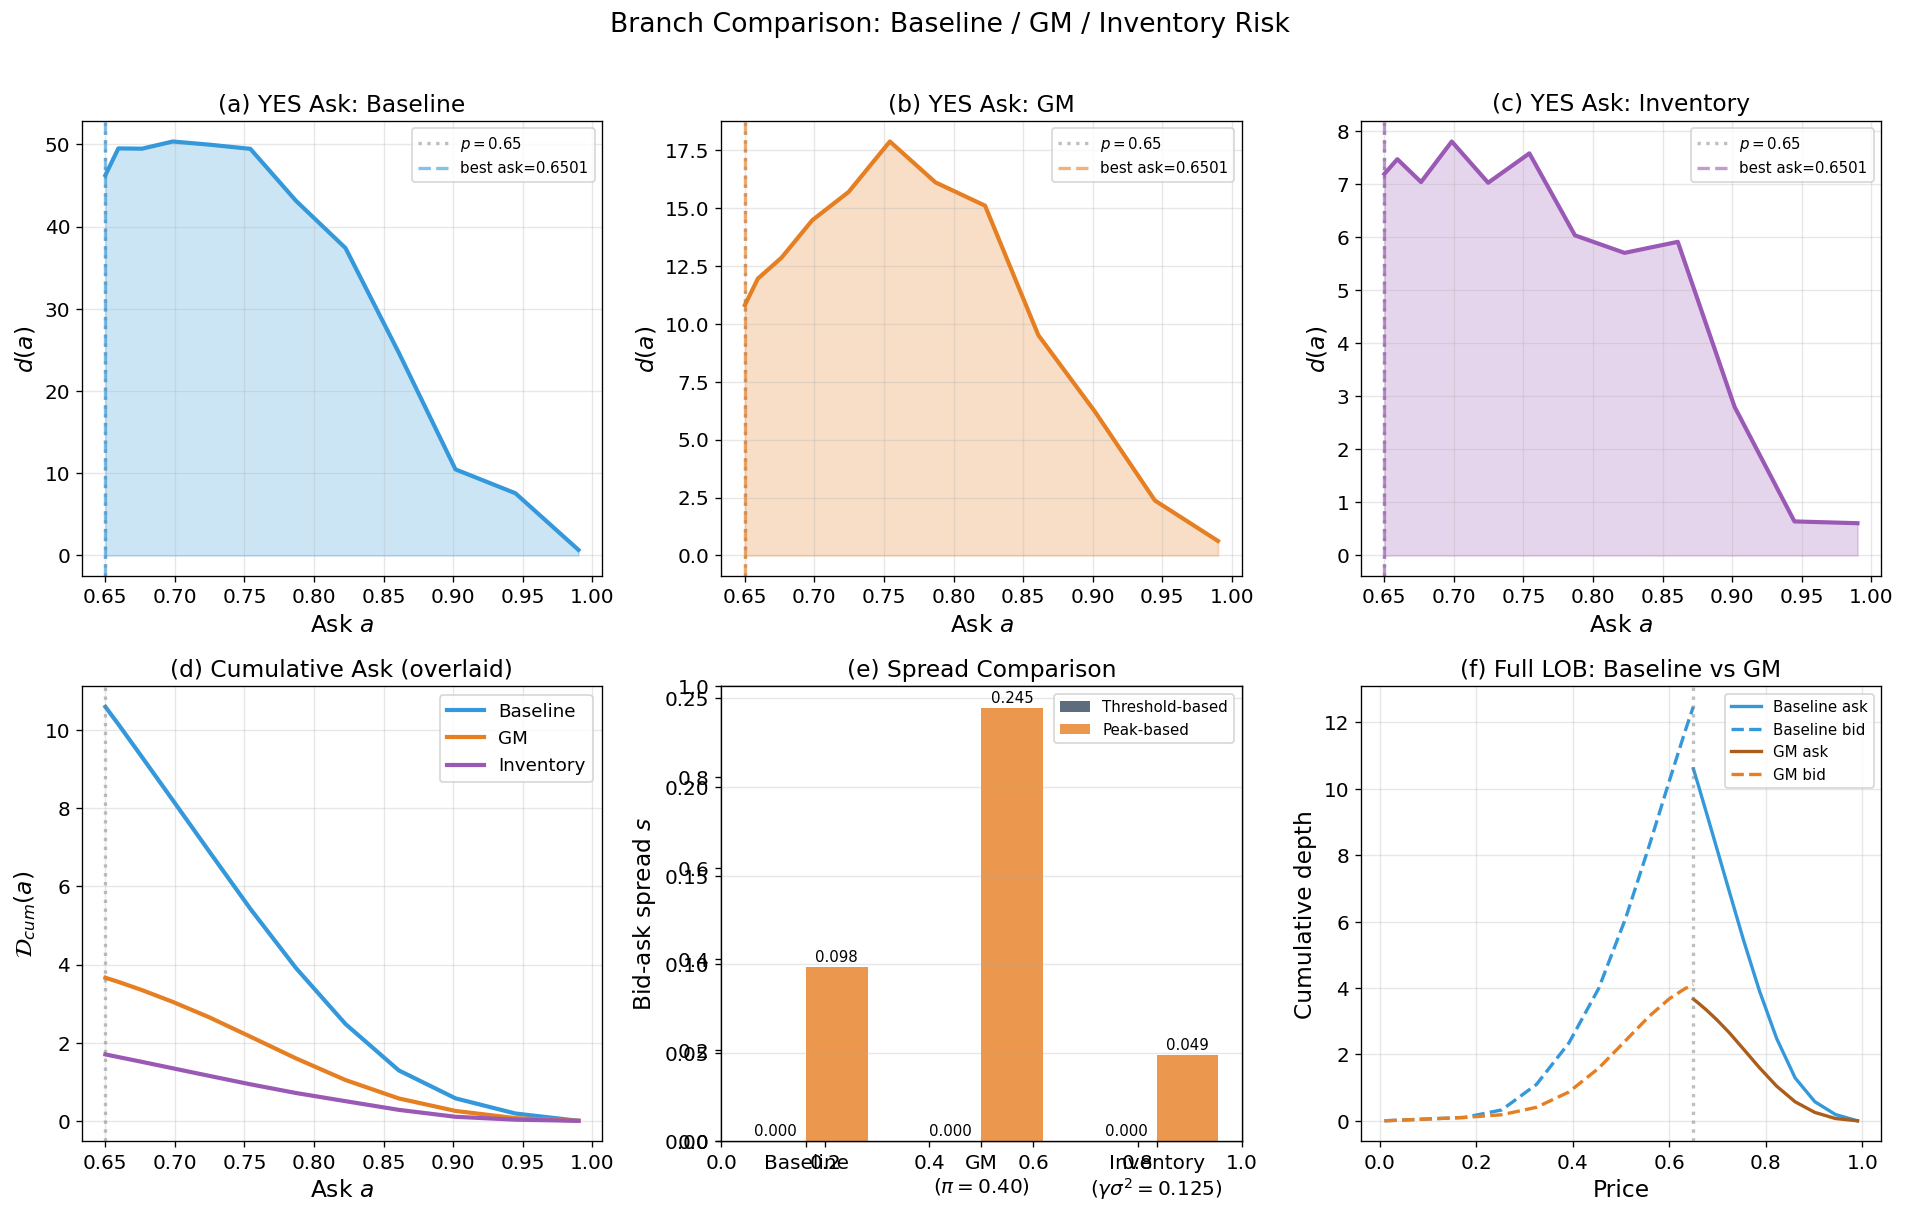

In [10]:
fig = plt.figure(figsize=(16, 10))

# Row 1: ask densities across branches
for col, (out, lbl, color) in enumerate([
    (yes_b, 'Baseline', '#3498db'),
    (yes_gm, 'GM', '#e67e22'),
    (yes_iv, 'Inventory', '#9b59b6')
]):
    ax = fig.add_subplot(2, 3, col + 1)
    ax.plot(out['a_grid'], out['d'], color=color, lw=2.5)
    ax.fill_between(out['a_grid'], 0, out['d'], alpha=0.25, color=color)
    ax.axvline(p_mid, color='gray', ls=':', alpha=0.5, label=f'$p={p_mid}$')
    ax.axvline(out['best_ask'], color=color, ls='--', alpha=0.6,
               label=f'best ask={out["best_ask"]:.4f}')
    ax.set_xlabel('Ask $a$'); ax.set_ylabel('$d(a)$')
    ax.set_title(f'({chr(97+col)}) YES Ask: {lbl}')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Row 2: overlay of all three cumulative depths + spread comparison
ax = fig.add_subplot(2, 3, 4)
for out, lbl, color in [(yes_b, 'Baseline', '#3498db'),
                         (yes_gm, 'GM', '#e67e22'),
                         (yes_iv, 'Inventory', '#9b59b6')]:
    ax.plot(out['a_grid'], out['d_cum'], color=color, lw=2.5, label=lbl)
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Ask $a$'); ax.set_ylabel(r'$\mathcal{D}_{cum}(a)$')
ax.set_title('(d) Cumulative Ask (overlaid)')
ax.legend(); ax.grid(True, alpha=0.3)

# Full LOB for each branch
for col, (yes_out, no_out, s, lbl, color) in enumerate([
    (yes_b, no_b, s_b, 'Baseline', '#3498db'),
    (yes_gm, no_gm, s_gm, 'GM', '#e67e22'),
    (yes_iv, no_iv, s_iv, 'Inventory', '#9b59b6')
]):
    if col == 0:
        ax = fig.add_subplot(2, 3, 5)
    else:
        continue

# Bar chart of spreads
ax = fig.add_subplot(2, 3, 5)
labels = ['Baseline', 'GM\n($\\pi=0.40$)', 'Inventory\n($\\gamma\\sigma^2=0.125$)']
thresh_spreads = [s_b, s_gm, s_iv]
peak_spreads = [sp_b, sp_gm, sp_iv]
x = np.arange(len(labels)); w = 0.35
bars1 = ax.bar(x - w/2, thresh_spreads, w, label='Threshold-based', color='#34495e', alpha=0.8)
bars2 = ax.bar(x + w/2, peak_spreads, w, label='Peak-based', color='#e67e22', alpha=0.8)
for bars, vals in [(bars1, thresh_spreads), (bars2, peak_spreads)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Bid-ask spread $s$')
ax.set_title('(e) Spread Comparison')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# Full LOBs: bid and ask together for baseline and GM
ax = fig.add_subplot(2, 3, 6)
# Baseline
b_grid_b = 1 - no_b['a_grid'][::-1]; dc_bid_b = np.zeros(len(b_grid_b))
for i in range(len(b_grid_b)):
    if i > 0: dc_bid_b[i] = np.trapz(no_b['d'][::-1][:i+1], b_grid_b[:i+1])
b_grid_gm = 1 - no_gm['a_grid'][::-1]; dc_bid_gm = np.zeros(len(b_grid_gm))
for i in range(len(b_grid_gm)):
    if i > 0: dc_bid_gm[i] = np.trapz(no_gm['d'][::-1][:i+1], b_grid_gm[:i+1])

ax.plot(yes_b['a_grid'], yes_b['d_cum'], color='#3498db', lw=2, label='Baseline ask')
ax.plot(b_grid_b, dc_bid_b, color='#3498db', lw=2, ls='--', label='Baseline bid')
ax.plot(yes_gm['a_grid'], yes_gm['d_cum'], color="#ab5e1b", lw=2, label='GM ask')
ax.plot(b_grid_gm, dc_bid_gm, color='#e67e22', lw=2, ls='--', label='GM bid')
ax.axvline(p_mid, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('Price'); ax.set_ylabel('Cumulative depth')
ax.set_title('(f) Full LOB: Baseline vs GM')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle(f'Branch Comparison: Baseline / GM / Inventory Risk',
             fontsize=16, y=1.01)
plt.tight_layout()


print(f"\n{'='*70}")
print("FINAL SUMMARY")
print(f"{'='*70}")
print(f"{'Scenario':<22} {'Best YES':<10} {'Best NO':<10} {'Thr spread':<12} {'Peak spread':<12}")
print("-" * 70)
print(f"{'Baseline':<22} {yes_b['best_ask']:<10.4f} {no_b['best_ask']:<10.4f} {s_b:<12.4f} {sp_b:<12.4f}")
print(f"{'Glosten-Milgrom':<22} {yes_gm['best_ask']:<10.4f} {no_gm['best_ask']:<10.4f} {s_gm:<12.4f} {sp_gm:<12.4f}")

## 9. Parameter sweep: spread vs $\pi$ (GM) and vs $\gamma\sigma_p^2$ (inventory)

Comparative statics — the core economic question: **how does the spread respond to the strength of each friction?** This generates the empirical-calibration targets. Given an observed Polymarket spread, we can back out the implied $\pi$ or $\gamma\sigma_p^2$.

In [ ]:
# Sweep GM: vary pi at fixed sigma_s = 0.30
print('='*60); print('Parameter sweep: GM'); print('='*60)
gm_pis = [0.0, 0.10, 0.20, 0.30, 0.40]
gm_sp_peak = []; gm_sp_thr = []
for pi_val in gm_pis:
    y, n, s_t, s_p = compute_full_lob(gm_pi=pi_val, gm_sigma_s=0.30,
                                        label=f'GM pi={pi_val}')
    gm_sp_peak.append(s_p); gm_sp_thr.append(s_t)

# Sweep inventory: vary gamma at fixed sigma_p = 0.25
print('\n' + '='*60); print('Parameter sweep: Inventory'); print('='*60)
gammas = [0.0, 0.5, 1.0, 2.0, 4.0]
iv_sp_peak = []; iv_sp_thr = []
for g in gammas:
    y, n, s_t, s_p = compute_full_lob(inventory_gamma=g, fundamental_sigma=0.25,
                                        label=f'Inv gamma={g}')
    iv_sp_peak.append(s_p); iv_sp_thr.append(s_t)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(gm_pis, gm_sp_peak, 'o-', color='#e67e22', lw=2.5, ms=8, label='Peak spread')
axes[0].plot(gm_pis, gm_sp_thr, 's--', color='#34495e', lw=1.5, ms=6, label='Threshold spread')
axes[0].set_xlabel(r'Informed share $\pi$')
axes[0].set_ylabel('Bid-ask spread $s$')
axes[0].set_title(r'GM sweep ($\sigma_s = 0.30$)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(gammas, iv_sp_peak, 'o-', color='#9b59b6', lw=2.5, ms=8, label='Peak spread')
axes[1].plot(gammas, iv_sp_thr, 's--', color='#34495e', lw=1.5, ms=6, label='Threshold spread')
axes[1].set_xlabel(r'Risk aversion $\gamma$')
axes[1].set_ylabel('Bid-ask spread $s$')
axes[1].set_title(r'Inventory sweep ($\sigma_p = 0.25$)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle('Comparative statics: spread vs friction strength', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\\nGM sweep (peak spread): {[round(s, 4) for s in gm_sp_peak]}')
print(f'Inventory sweep (peak spread): {[round(s, 4) for s in iv_sp_peak]}')

Parameter sweep: GM

Scenario: GM pi=0.0

--- YES (p=0.650, pi=0.0, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.0000, ask grid: [0.6501, 0.9900]
  Done [62s]. Best ask = 0.6501, floor binds = True

--- NO (p=0.350, pi=0.0, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.0000, ask grid: [0.3501, 0.9900]
  Done [173s]. Best ask = 0.3501, floor binds = True

GM pi=0.0:
  Threshold-based: YES=0.6501, NO=0.3501, spread=0.0002
  Peak-based:      YES=0.6985, NO=0.3997, spread=0.0982

Scenario: GM pi=0.1

--- YES (p=0.650, pi=0.1, gamma*sigma^2=0.0000) ---
  Delta_AS = 0.0300, ask grid: [0.6501, 0.9900]


## 10. Interpretation

**Why two spread definitions?** In prediction-market equilibrium, a small tail of impatient LPs with thin margins always clusters near the no-arbitrage floor, regardless of extensions. The *threshold-based* spread is dominated by this tail. What the extensions genuinely move is the *modal posting behaviour* — where the bulk of LP capital sits. The *peak-based* spread captures this and should be the headline metric for comparative statics.

**GM mechanism.** Adverse selection shifts $m_{\text{eff}}$ down by $\Delta_{\text{AS}} = \pi \sigma_s$ uniformly across $a$. This hurts low-$a$ posting more in percentage terms (small margin → larger relative cut), so LPs migrate to higher $a$. The peak spread widens monotonically in $\pi$.

**Inventory risk.** The $q^2$ cost penalises *deep* posting regardless of price. LPs reduce their steady-state depth; marginal impact on where to post is second-order. Peak spread decreases or stays roughly constant in $\gamma$ — the story here is about *depth reduction* rather than *price migration*. This is a genuine model prediction: inventory risk in isolation does not generate a large spread.

**Implication for the paper.** If empirical Polymarket spreads are large (say 2–5 cents on contested contracts), Glosten–Milgrom is the quantitatively dominant channel. Inventory risk alone cannot generate those spreads under plausible $\gamma, \sigma_p$. This narrows the calibration story: fit $\pi$ to observed spreads, treat inventory risk as secondary.

## 11. Limitations

- $\Delta_{\text{AS}}$ treated as a constant approximation, not state-dependent. A richer Glosten–Milgrom formulation would let it depend on $a$ via Bayesian updating (informed traders' probability of being above $a$).
- Inventory risk uses a CARA / quadratic approximation valid only for small $q \sigma_p$. For large inventories the approximation breaks down.
- Both extensions retain the continuous-price assumption. A minimum-tick constraint would combine naturally with either and should be added for empirical calibration.